## Counting Based Approach

In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines() 

In [3]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

In [7]:
freq_map = {}

for w in words:
    for ch1, ch2 in zip(w, w[1:]):
        bigram = (ch1, ch2)
        freq_map[bigram] = freq_map.get(bigram, 0) + 1

In [8]:
freq_map[('a', 'b')]

541

In [9]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [10]:
chars = sorted(list(set("".join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [11]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

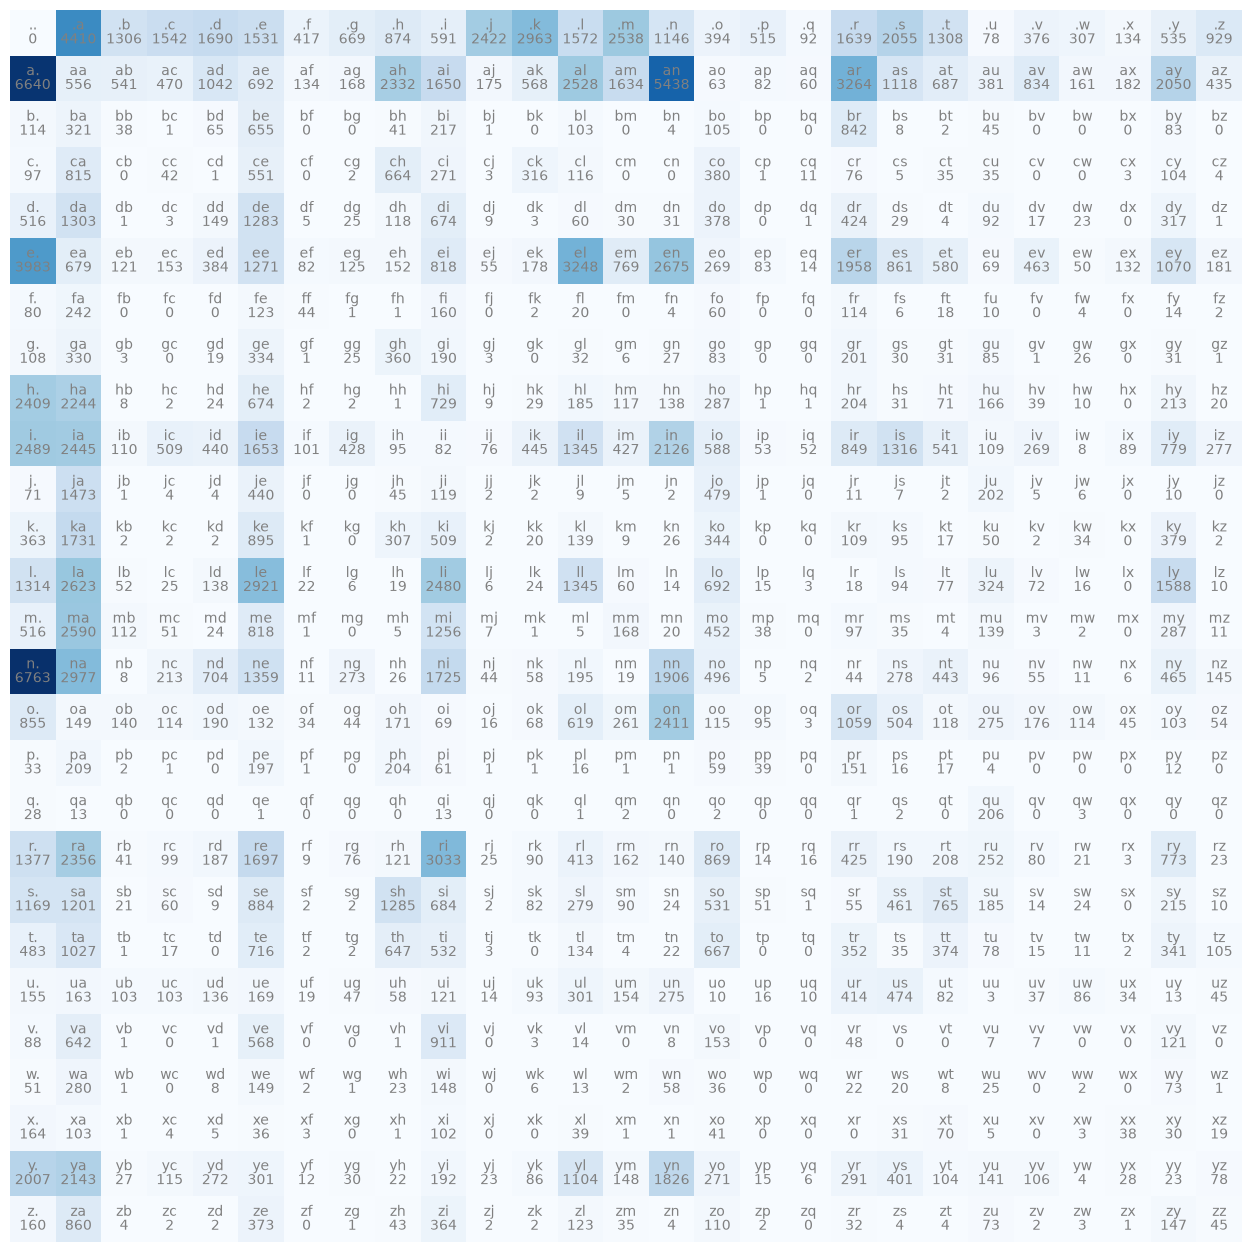

In [12]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [13]:
gen = torch.Generator().manual_seed(42)

In [14]:
p = N[0].float()
p /= p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [15]:
p.sum()

tensor(1.)

In [16]:
gen = torch.Generator().manual_seed(42)
idx = torch.multinomial(p, num_samples=1, replacement=True, generator=gen).item()
itos[idx]

'a'

In [17]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)
P

tensor([[3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
         1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
         4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
         5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
         4.2109e-03, 1.6719e-02, 2.9008e-02],
        [1.9583e-01, 1.6425e-02, 1.5983e-02, 1.3889e-02, 3.0756e-02, 2.0435e-02,
         3.9809e-03, 4.9835e-03, 6.8796e-02, 4.8685e-02, 5.1899e-03, 1.6779e-02,
         7.4575e-02, 4.8213e-02, 1.6039e-01, 1.8872e-03, 2.4475e-03, 1.7988e-03,
         9.6279e-02, 3.2997e-02, 2.0288e-02, 1.1264e-02, 2.4623e-02, 4.7771e-03,
         5.3963e-03, 6.0480e-02, 1.2857e-02],
        [4.3039e-02, 1.2051e-01, 1.4596e-02, 7.4850e-04, 2.4701e-02, 2.4551e-01,
         3.7425e-04, 3.7425e-04, 1.5719e-02, 8.1587e-02, 7.4850e-04, 3.7425e-04,
         3.8922e-02, 3.7425e-04, 1.8713e-03, 3.9671e-02, 3.7425e-04, 3.7425e-04,
         3.1549e-

In [18]:
gen = torch.Generator().manual_seed(42)

for i in range(10):
    out = []
    idx = 0

    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=gen).item()
        out.append(itos[idx])
        if idx == 0:
            break

    print('.'.join(out))

a.n.u.g.e.e.n.v.i..
s..
m.a.b.i.d.u.s.h.a.n..
s.t.a.n..
s.i.l.a.y.l.e.l.a.r.e.m.a.h..
l.i..
l.e..
e.p.i.a.c.h.a.l.e.n..
d.i.z.a..
k..


In [19]:
log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


## Neural Network Approach

In [20]:
# Prepare the training set
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)


In [21]:
xs

[0, 5, 13, 13, 1]

In [22]:
ys

[5, 13, 13, 1, 0]

In [23]:
xs = torch.tensor(xs, dtype=torch.int64)
ys = torch.tensor(ys, dtype=torch.int64)

In [24]:
# One hot encode the inputs

import torch.nn.functional as F

xs_enc = F.one_hot(xs, num_classes=27).float()

In [25]:
xs_enc.dtype

torch.float32

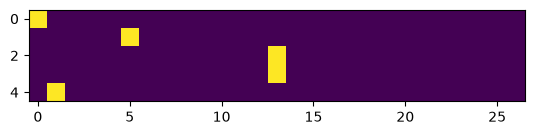

In [26]:
plt.imshow(xs_enc)

In [27]:
gen = torch.Generator().manual_seed(42)

W = torch.randn((27, 27), generator=gen, requires_grad=True)

In [28]:
# Forward Pass

logits = xs_enc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [29]:
loss.item()

4.372129440307617

In [30]:
# Backward Pass
W.grad = None
loss.backward()
W.data += -0.1 * W.grad

In [31]:
# Prepare the entire training set
import torch.nn.functional as F

xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs, dtype=torch.int64)
ys = torch.tensor(ys, dtype=torch.int64)

xs_enc = F.one_hot(xs, num_classes=27).float()

In [32]:
# Initialize the weights and network

gen = torch.Generator().manual_seed(42)
W = torch.randn((27, 27), generator=gen, requires_grad=True)

In [36]:
# Gradient Descent
epochs = 100
lr = 50.0

for i in range(epochs+1):
    # Forward pass
    logits = xs_enc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    regularization_term = 0.01*(W**2).mean()
    loss = -probs[torch.arange((xs.nelement())), ys].log().mean() + regularization_term

    # Backward pass
    W.grad = None
    loss.backward()
    W.data += -lr * W.grad

    if i % 10 == 0:
        print(f'Epoch {i}, Loss: {loss.item()}')

Epoch 0, Loss: 2.4899914264678955
Epoch 10, Loss: 2.488555669784546
Epoch 20, Loss: 2.487406015396118
Epoch 30, Loss: 2.4864706993103027
Epoch 40, Loss: 2.4857003688812256
Epoch 50, Loss: 2.485058546066284
Epoch 60, Loss: 2.484518051147461
Epoch 70, Loss: 2.4840588569641113
Epoch 80, Loss: 2.483665943145752
Epoch 90, Loss: 2.4833273887634277
Epoch 100, Loss: 2.4830334186553955


In [37]:
# Sample from the network
gen = torch.Generator().manual_seed(42)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=gen).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

anugeenvi.
s.
mabidushximuben.
silaylelaremah.
li.
